In [1]:
!pip install gym==0.26.2 gymnasium pygame


     ---------------------------------------- 0.0/721.7 kB ? eta -:--:--
     ---------------------------------------- 0.0/721.7 kB ? eta -:--:--
     ---------------------------------------- 0.0/721.7 kB ? eta -:--:--
     ---------------------------------------- 0.0/721.7 kB ? eta -:--:--
     ---------------------------------------- 0.0/721.7 kB ? eta -:--:--
     ---------------------------------------- 0.0/721.7 kB ? eta -:--:--
     ---------------------------------------- 0.0/721.7 kB ? eta -:--:--
     ---------------------------------------- 0.0/721.7 kB ? eta -:--:--
     -------------- ------------------------- 262.1/721.7 kB ? eta -:--:--
     -------------- ------------------------- 262.1/721.7 kB ? eta -:--:--
     -------------------------- --------- 524.3/721.7 kB 762.0 kB/s eta 0:00:01
     --------------------------------------- 721.7/721.7 kB 735.3 kB/s  0:00:02
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Ge


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install gymnasium[atari] gymnasium[mujoco]


   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.5 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.5 MB ? eta -:--:--
   ------ --------------------------------- 0.5/3.5 MB 479.2 kB/s eta 0:00:07
   ------ --------------------------------- 0.5/3.5 MB 479.2 kB/s eta 0:00:07
   ------ --------------------------------- 0.5/3.5 MB 479.2 kB/s eta 0:00:07
   --------- ------------------------------ 0.8/3.5 MB 459.9 kB/s eta 0:00:06
   --------- ------------------------------ 0.8/3.5 MB 459.9 kB/s eta 0:00:06
   --------- ------------------------------ 0.8/3.5 MB 459.9 kB/s eta 0:00:06
   ------------ --------------------------- 1.0/3.5 MB 466.2 kB/s eta 0:00:06
   ------------ --------------------------- 1.0/3.5 MB 466.2 kB/s eta 0:00:06
   --------------- ------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!python -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------------- ---------------------- 0.8/1.8 MB 1.1 MB/s eta 0:00:01
   ----------------- ---------------------- 0.8/1.8 MB 1.1 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 824.4 kB/s eta 0:00:01
   ----------------------------- ---------- 1.3/1.8 MB 944.7 kB/s eta 0:00:01
   ----------------------------------- ---- 1.6/1.8 MB 911.5 kB/s eta 0:00:01
   ----------------------------------- ---- 1.6/1.8 MB 911.5 kB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 851.0 kB/s  0:00:02
  Attempting uninstall: pip
    Found existing 

In [4]:
import gym
print("Gym version:", gym.__version__)


Gym version: 0.26.2


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [1]:
import numpy as np
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

import gym

env = gym.make("CartPole-v1", render_mode="human")
observation, info = env.reset()

for step in range(500):
    action = env.action_space.sample()
    observation, reward, done, truncated, info = env.step(action)
    if done or truncated:
        observation, info = env.reset()
env.close()


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
C:\Users\Rudra Sharma\AppData\Local\Programs\Python\Python312\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


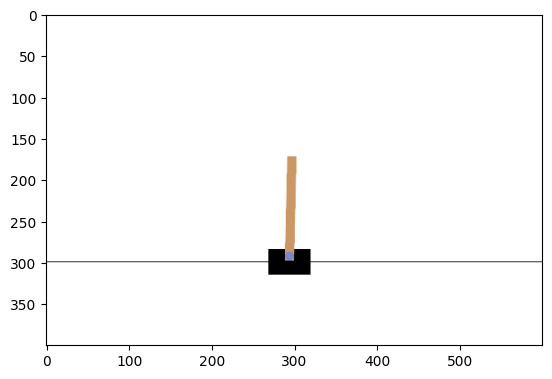

In [3]:
import gym
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib import animation

env = gym.make("CartPole-v1", render_mode="rgb_array")
frames = []
obs = env.reset()

for _ in range(200):
    frame = env.render()
    frames.append(frame)
    action = env.action_space.sample()
    obs, reward, done, truncated, info = env.step(action)
    if done or truncated:
        obs = env.reset()
env.close()

fig = plt.figure()
im = plt.imshow(frames[0])

def animate(i):
    im.set_array(frames[i])
    return [im]

anim = animation.FuncAnimation(fig, animate, frames=len(frames), interval=30)
HTML(anim.to_jshtml())


Number of states: 16
Number of actions: 4
Training finished!
States visited in test episode: [0, 4, 8, 9, 13, 14, 15]


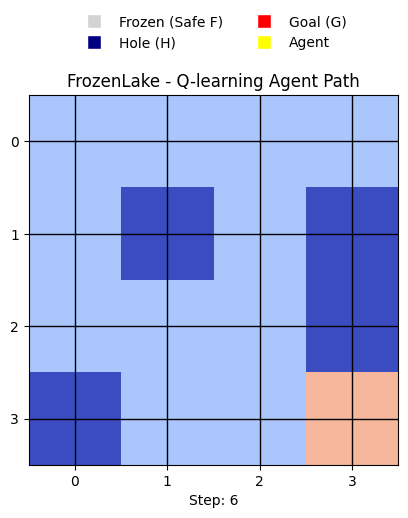

In [4]:
# ================================
# Q-Learning on FrozenLake with Animation
# ================================




        # ε-greedy policy: sometimes random, sometimes best known
        if np.random.rand() < epsilon:
            action = env.action_space.sample()  # explore
        else:
            action = np.argmax(Q[state])        # exploit

        result = env.step(action)

        # Handle gym's different return formats
        if len(result) == 5:
            new_state, reward, done, truncated, info = result
            done = done or truncated
        else:
            new_state, reward, done, info = result

        # Q-learning update
        old_value = Q[state, action]
        next_max = np.max(Q[new_state])
        Q[state, action] = old_value + alpha * (reward + gamma * next_max - old_value)

        state = new_state

        if done:
            break

    # Decay exploration rate
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

print("Training finished!")

# -------------------------
# 5. Collect one greedy episode (for animation)
# -------------------------
def run_greedy_episode(env, Q):
    """Run one episode using the learned Q-table, return list of visited states."""
    states_visited = []

    state = env.reset()
    if isinstance(state, tuple):
        state = state[0]

    states_visited.append(state)

    for step in range(max_steps):
        action = np.argmax(Q[state])       # always choose best action
        result = env.step(action)

        if len(result) == 5:
            new_state, reward, done, truncated, info = result
            done = done or truncated
        else:
            new_state, reward, done, info = result

        states_visited.append(new_state)
        state = new_state

        if done:
            break

    return states_visited

states_visited = run_greedy_episode(env, Q)
print("States visited in test episode:", states_visited)

# -------------------------
# 6. Prepare Grid for Animation
# -------------------------
# Get the map layout from environment (S, F, H, G)
desc = env.unwrapped.desc  # 2D array of bytes
n_rows, n_cols = desc.shape

# Build a static background grid:
#  0 = frozen (F)
# -1 = hole (H)
#  2 = goal (G)
background = np.zeros((n_rows, n_cols))

for r in range(n_rows):
    for c in range(n_cols):
        cell = desc[r, c].decode("utf-8")
        if cell == 'H':
            background[r, c] = -1
        elif cell == 'G':
            background[r, c] = 2
        else:
            background[r, c] = 0

# -------------------------
# 7. Build animation frames (agent position over time)
# -------------------------
frames = []

for s in states_visited:
    frame = background.copy()
    r, c = divmod(s, n_cols)
    # Mark agent position with value 1
    frame[r, c] = 1
    frames.append(frame)

# -------------------------
# 8. Create Animation with matplotlib
# -------------------------
fig, ax = plt.subplots()
im = ax.imshow(frames[0], cmap="coolwarm", vmin=-1, vmax=2)

ax.set_title("FrozenLake - Q-learning Agent Path")
ax.set_xticks(range(n_cols))
ax.set_yticks(range(n_rows))
ax.set_xticklabels(range(n_cols))
ax.set_yticklabels(range(n_rows))
ax.grid(which="both", color="black", linewidth=1)

# Add a color legend explanation (optional)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Frozen (Safe F)',
           markerfacecolor='lightgray', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Hole (H)',
           markerfacecolor='navy', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Goal (G)',
           markerfacecolor='red', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Agent',
           markerfacecolor='yellow', markersize=10),
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.25),
          ncol=2, frameon=False)

def update(frame_idx):
    im.set_array(frames[frame_idx])
    ax.set_xlabel(f"Step: {frame_idx}")
    return [im]

anim = animation.FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=600,   # milliseconds between frames (slower for clarity)
    blit=True
)

# If you're in Jupyter Notebook, uncomment this:
from IPython.display import HTML
HTML(anim.to_jshtml())

# If you're running as a .py script, uncomment this instead:
# plt.show()


✅ Training finished with slippery=True!
States visited in test episode: [0, 0, 4, 4, 8, 8, 8, 4, 0, 1, 0, 0, 1, 0, 4, 8, 8, 8, 9, 10, 9, 10, 9, 8, 9, 13, 14, 13, 14, 13, 9, 8, 8, 8, 4, 8, 9, 13, 9, 10, 6, 10, 6, 7]


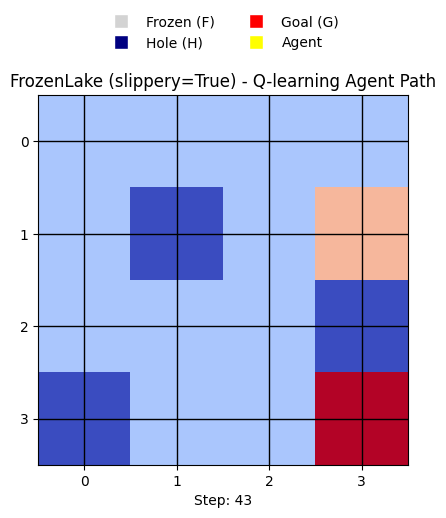

In [5]:
# -------------------------
# FROZENLAKE Q-LEARNING (Slippery = True)
# -------------------------

import numpy as np
import gym
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# -------------------------
# 1. Create Environment
# -------------------------
env = gym.make("FrozenLake-v1", is_slippery=True)  # Slippery enabled!

n_states = env.observation_space.n
n_actions = env.action_space.n

# -------------------------
# 2. Initialize Q-table
# -------------------------
Q = np.zeros((n_states, n_actions))

# Hyperparameters
alpha = 0.8        # learning rate
gamma = 0.95       # discount factor
epsilon = 1.0      # exploration rate
epsilon_min = 0.01
epsilon_decay = 0.995
episodes = 5000
max_steps = 100

# -------------------------
# 3. Training Loop
# -------------------------
for episode in range(episodes):
    state = env.reset()
    if isinstance(state, tuple):
        state = state[0]

    for step in range(max_steps):
        # ε-greedy policy: sometimes random, sometimes best known
        if np.random.rand() < epsilon:
            action = env.action_space.sample()  # explore
        else:
            action = np.argmax(Q[state])        # exploit

        result = env.step(action)

        # Handle gym's different return formats
        if len(result) == 5:
            new_state, reward, done, truncated, info = result
            done = done or truncated
        else:
            new_state, reward, done, info = result

        # Q-learning update rule
        old_value = Q[state, action]
        next_max = np.max(Q[new_state])
        Q[state, action] = old_value + alpha * (reward + gamma * next_max - old_value)

        state = new_state

        if done:
            break

    # Decay exploration rate
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

print("✅ Training finished with slippery=True!")

# -------------------------
# 4. Run one greedy episode (for animation)
# -------------------------
def run_greedy_episode(env, Q):
    """Run one episode using the learned Q-table, return list of visited states."""
    states_visited = []
    state = env.reset()
    if isinstance(state, tuple):
        state = state[0]
    states_visited.append(state)

    for step in range(max_steps):
        action = np.argmax(Q[state])  # always choose best action
        result = env.step(action)

        if len(result) == 5:
            new_state, reward, done, truncated, info = result
            done = done or truncated
        else:
            new_state, reward, done, info = result

        states_visited.append(new_state)
        state = new_state

        if done:
            break

    return states_visited

states_visited = run_greedy_episode(env, Q)
print("States visited in test episode:", states_visited)

# -------------------------
# 5. Prepare Grid for Animation
# -------------------------
desc = env.unwrapped.desc  # 2D array of bytes
n_rows, n_cols = desc.shape

background = np.zeros((n_rows, n_cols))
for r in range(n_rows):
    for c in range(n_cols):
        cell = desc[r, c].decode("utf-8")
        if cell == 'H':
            background[r, c] = -1
        elif cell == 'G':
            background[r, c] = 2
        else:
            background[r, c] = 0

# -------------------------
# 6. Build animation frames
# -------------------------
frames = []
for s in states_visited:
    frame = background.copy()
    r, c = divmod(s, n_cols)
    frame[r, c] = 1  # agent position
    frames.append(frame)

# -------------------------
# 7. Create Animation
# -------------------------
fig, ax = plt.subplots()
im = ax.imshow(frames[0], cmap="coolwarm", vmin=-1, vmax=2)
ax.set_title("FrozenLake (slippery=True) - Q-learning Agent Path")
ax.set_xticks(range(n_cols))
ax.set_yticks(range(n_rows))
ax.grid(which="both", color="black", linewidth=1)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Frozen (F)',
           markerfacecolor='lightgray', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Hole (H)',
           markerfacecolor='navy', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Goal (G)',
           markerfacecolor='red', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Agent',
           markerfacecolor='yellow', markersize=10),
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.25),
          ncol=2, frameon=False)

def update(frame_idx):
    im.set_array(frames[frame_idx])
    ax.set_xlabel(f"Step: {frame_idx}")
    return [im]

anim = animation.FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=600,
    blit=True
)

HTML(anim.to_jshtml())
